# FFC U-Net 으로 역합성곱

**번진 영상 → 원본 영상.** 잡음은 다루지 않는다.

## 왜 FFC 인가

다이폴 커널은 **주파수 영역에서 정의된 열화**다. 특정 방향의 성분이 통째로 지워진다.
그런데 보통의 합성곱은 3x3 이웃만 본다 — 열화가 사는 곳과 다른 곳에서 일한다.

**FFC(Fast Fourier Convolution)** 는 채널을 두 갈래로 나눈다.

| 갈래 | 하는 일 | 보는 범위 |
|---|---|---|
| 국소 | 평범한 3x3 합성곱 | 가까운 이웃 |
| **전역** | **FFT → 1x1 합성곱 → 역FFT** | **이미지 전체를 한 번에** |

전역 갈래가 한 층만으로 모든 주파수 성분을 동시에 보고 고칠 수 있다.
어텐션이 없어 GPU 활용률도 높다.

## 목표

| 방법 | PSNR | SSIM |
|---|---|---|
| 입력 (번진 영상) | 7.892 | 0.032 |
| 예시 U-Net | 25.586 | 0.878 |
| **TKD ← 목표** | **31.187** | **0.934** |
| 위너 (참고, 최종 제출 불가) | 42.251 | 0.988 |


## 1. Drive 마운트 + 데이터 준비

In [ ]:
from pathlib import Path

import torch
from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/project5")     # TODO: 본인 경로
RUN_DIR = DRIVE_ROOT / "logs_deconv_ffc_v2"   # v1(방향 6개, 주파수 정보 없음) 과 분리
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_LAST, CKPT_BEST = RUN_DIR / "checkpoint_last.ckpt", RUN_DIR / "checkpoint_best.ckpt"
HISTORY = RUN_DIR / "history.json"

LOCAL_CKPT = Path("/content/ckpt_deconv_v2"); LOCAL_CKPT.mkdir(parents=True, exist_ok=True)
LOCAL_LAST, LOCAL_BEST = LOCAL_CKPT / "last.ckpt", LOCAL_CKPT / "best.ckpt"
DRIVE_SYNC_EVERY = 30

LOCAL_ROOT = Path("/content/work"); LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

# 2단계는 원본 영상만 있으면 된다. 번짐은 다이폴 커널로 직접 만들고, 잡음은
# 1단계를 통과시켜 만든다. 그래서 1일차 zip 하나면 충분하다.
NEEDED = ["train", "val", "test_label"]


def still_missing():
    return [n for n in NEEDED if not any(LOCAL_ROOT.glob(f"{n}/**/*.npy"))]


print("Drive 안에 있는 것:")
for p in sorted(DRIVE_ROOT.glob("*")):
    size = f"{p.stat().st_size/1e6:.0f} MB" if p.is_file() else "(폴더)"
    print(f"   {p.name:<32}{size}")

for zip_name in ("dataset.zip", "dataset_deconv.zip"):
    if not still_missing():
        break
    z = DRIVE_ROOT / zip_name
    if z.exists():
        print(f"푸는 중: {zip_name}")
        !cp "{z}" /content/_d.zip
        !unzip -q -o /content/_d.zip -d "{LOCAL_ROOT}"

left = still_missing()
if left:
    print("")
    print("/content/work 안에 실제로 있는 것:")
    for p in sorted(LOCAL_ROOT.rglob("*"))[:40]:
        if p.is_dir():
            print(f"   {p.relative_to(LOCAL_ROOT)}/   npy {len(list(p.glob('*.npy')))}")
    raise FileNotFoundError(
        "아직 없는 폴더: " + str(left) + "  ->  위 목록과 대조할 것. "
        "Drive 의 project5 폴더에 dataset.zip 이 있어야 한다.")


def find_npy_dir(base: Path) -> Path:
    """폴더가 한 겹 더 중첩된 경우까지 훑는다."""
    if any(base.glob("*.npy")):
        return base
    for sub in sorted(d for d in base.iterdir() if d.is_dir()):
        if any(sub.glob("*.npy")):
            return sub
    raise FileNotFoundError(base)


TRAIN_DIR = find_npy_dir(LOCAL_ROOT / "train")
VAL_DIR = find_npy_dir(LOCAL_ROOT / "val")
TEST_LABEL_DIR = find_npy_dir(LOCAL_ROOT / "test_label")

print("")
for n, d in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test_label", TEST_LABEL_DIR)]:
    print(f"  {n:12s} {len(list(d.glob('*.npy'))):5d}")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive 안에 있는 것:
   code_denoising                  (폴더)
   dataset.zip                     1696 MB
   dataset_deconv.zip              79 MB
   logs_deconv                     (폴더)
   logs_deconv_ffc                 (폴더)
   logs_deconv_ffc_v2              (폴더)
   logs_deconv_ffc_v2_frozen       (폴더)
   logs_denoise_ffc_blur           (폴더)
   logs_denoising                  (폴더)
   logs_ffc                        (폴더)
   logs_restormer                  (폴더)

  train         7268
  val            100
  test_label     100
GPU: NVIDIA A100-SXM4-80GB


## 2. 설정

FFC 는 빠르므로 **256x256 전체**로 학습한다. 조각으로 자르지 않으므로
`physics_weight` 물리 항이 그대로 살아 있다.


In [ ]:
import json, math, random, time, shutil, zlib
from dataclasses import dataclass, asdict

import numpy as np
import torch.nn.functional as F
from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


@dataclass
class FFCConfig:
    in_ch: int = 1
    out_ch: int = 1
    width: int = 48           # 첫 단계 채널 수
    depth: int = 3            # 해상도를 몇 번 줄일지
    n_blocks: int = 6         # 병목의 FFC 블록 개수
    ratio_g: float = 0.5      # 전역(주파수) 갈래에 배정할 채널 비율


@dataclass
class TrainConfig:
    epochs: int = 960
    batch: int = 16
    lr: float = 3e-4
    lr_min: float = 1e-6
    weight_decay: float = 1e-4
    grad_clip: float = 0.5
    num_workers: int = 8
    val_batch: int = 8
    amp: bool = True
    seed: int = 0
    physics_weight: float = 0.1     # 물리 항의 비중


# ─── 2단계가 실제로 받게 될 입력을 무엇으로 흉내낼 것인가 ────────────────
# 시험 때 이 모델에 들어오는 것은 1단계(FFC 잡음 제거)의 출력이다. 학습 입력이
# 깨끗한 번진 영상이면 학습과 시험의 입력 분포가 어긋나고, 역합성곱은 그
# 어긋남을 최대 44,074 배까지 증폭한다. 그래서 학습 입력도 같은 분포로 만든다.
#
#   "frozen" : 얼린 1단계를 학습 고리 안에서 실제로 통과시킨다. 분포가 정확히
#              일치한다. epoch 당 순전파가 하나 늘어 약 30~40 % 느려진다.
#   "noise"  : 가우시안 잡음으로 근사한다. 빠르지만 1단계 잔차의 주파수 구성
#              (특히 rician 의 저주파 밝기 편향) 은 재현하지 못한다.
#   "none"   : 깨끗한 번진 영상. 분포 불일치 — 비교용으로만 쓸 것.
# ─── 한 epoch 을 얼마나 짧게 볼 것인가 ─────────────────────────────────
# 학습 영상이 7268 장이라 전체를 한 번 도는 데 약 1.65 분이 걸린다. 시간이
# 짧을 때 이대로 두면 코사인 감쇠가 몇 칸 못 내려가고 끝난다. 매 epoch 마다
# 무작위로 1/EPOCH_FRACTION 만 뽑아 쓰면, 총 보는 장수는 같으면서 epoch 수가
# 그만큼 늘어 학습률 곡선이 끝까지 내려간다. 1 이면 전체를 쓴다.
EPOCH_FRACTION = 4

# "e2e" 로 바꾸면 1단계 없이 한 모델이 번짐+잡음 -> 원본 을 통째로 배운다.
# 조교 end-to-end U-Net(25.02 dB) 과 같은 구도의 대조 실험용이다.
STAGE1_MODE = "frozen"
STAGE1_CKPT = DRIVE_ROOT / "logs_denoise_ffc_blur" / "checkpoint_best.ckpt"
INPUT_NOISE_RANGE = (0.006, 0.018)      # "noise" 모드에서 표준편차를 뽑는 범위

# "frozen" 모드에서 1단계에 먹일 잡음. 1단계 학습 때와 같은 설정이어야 한다.
NOISE_RANGES = {"gaussian": (0.0, 0.1), "rician": (0.0, 0.15),
                "uniform": (0.0, 0.2), "salt_and_pepper": (0.0, 0.2)}

# ─── 어느 방향의 번짐을 배울 것인가 ─────────────────────────────────────
# 시험은 B0 = (0, 1) 한 방향뿐이다 (조교 공지: dipole (0,1) 은 알고 있다는 가정).
# 학습에서 방향을 6개로 흩으면 신경망은 정작 필요한 역연산 하나가 아니라 여섯
# 개를 배우게 되고, 지금처럼 용량이 모자란 상황에서는 그만큼 손해다.
#   False 로 두면 예전처럼 6개 방향을 무작위로 쓴다.
#   ※ 최종 시험이 여러 방향이면 True 는 치명적이다. 조교 확인 필요.
FIX_ORIENTATION = True

# ─── 다이폴 커널을 주파수 갈래에 직접 알려줄 것인가 ──────────────────────
# FFC 의 주파수 갈래는 1x1 합성곱이라 모든 주파수에 같은 가중치를 쓴다. 그런데
# 다이폴 역연산이 필요로 하는 이득 1/D(k) 는 주파수에 따라 44,074 배까지
# 벌어진다 — 지금 구조로는 표현할 수 없는 함수다. 각 주파수 자리에 D 값을
# 채널로 함께 넣어 주면 1x1 합성곱이 주파수마다 다른 이득을 만들 수 있다.
# 방향이 고정돼 있어야 D 가 상수 지도가 되므로 FIX_ORIENTATION 에 딸려 있다.
USE_DIPOLE_FEATURE = True

NUM_ORIENTATIONS = 6
VAL_ORIENTATION = 3          # 90도 — 실습 로그와 동일 조건 (입력 7.892 dB)
TKD_THRESHOLD, WIENER_K = 0.1, 1e-3
IMG_SIZE = 256

model_cfg, train_cfg = FFCConfig(), TrainConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_dtype = torch.bfloat16 if train_cfg.amp else None

random.seed(train_cfg.seed); np.random.seed(train_cfg.seed); torch.manual_seed(train_cfg.seed)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

for k, v in asdict(train_cfg).items():
    print(f"  {k}: {v}")
print(f"  STAGE1_MODE: {STAGE1_MODE}")
if USE_DIPOLE_FEATURE and not FIX_ORIENTATION:
    USE_DIPOLE_FEATURE = False
    print("  방향이 고정되지 않아 다이폴 채널을 끈다")
print(f"  FIX_ORIENTATION: {FIX_ORIENTATION}   USE_DIPOLE_FEATURE: {USE_DIPOLE_FEATURE}")

# 모드마다 체크포인트를 섞이지 않게 나눈다 (모델 모양이 같아서 섞이면 조용히 오염된다)
RUN_DIR = DRIVE_ROOT / f"logs_deconv_ffc_v2_{STAGE1_MODE}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
CKPT_LAST, CKPT_BEST = RUN_DIR / "checkpoint_last.ckpt", RUN_DIR / "checkpoint_best.ckpt"
HISTORY = RUN_DIR / "history.json"
LOCAL_CKPT = Path(f"/content/ckpt_deconv_{STAGE1_MODE}")
LOCAL_CKPT.mkdir(parents=True, exist_ok=True)
LOCAL_LAST, LOCAL_BEST = LOCAL_CKPT / "last.ckpt", LOCAL_CKPT / "best.ckpt"
print(f"  저장: {RUN_DIR}")

  epochs: 960
  batch: 16
  lr: 0.0003
  lr_min: 1e-06
  weight_decay: 0.0001
  grad_clip: 0.5
  num_workers: 8
  val_batch: 8
  amp: True
  seed: 0
  physics_weight: 0.1
  STAGE1_MODE: frozen
  FIX_ORIENTATION: True   USE_DIPOLE_FEATURE: True
  저장: /content/drive/MyDrive/project5/logs_deconv_ffc_v2_frozen


## 3. PSNR / SSIM — 실습 노트북과 동일 구현

In [11]:
class SSIMcal(torch.nn.Module):
    def __init__(self, win: int = 11, k1: float = 0.01, k2: float = 0.03):
        super().__init__()
        self.k1, self.k2 = k1, k2
        self.register_buffer("w", torch.ones(1, 1, win, win) / win**2)
        self.cov_norm = win**2 / (win**2 - 1)

    def forward(self, img, ref, dr):
        dr = dr[:, None, None, None]
        C1, C2 = (self.k1 * dr) ** 2, (self.k2 * dr) ** 2
        w = self.w.to(img.device)
        ux, uy = F.conv2d(img, w), F.conv2d(ref, w)
        uxx, uyy = F.conv2d(img * img, w), F.conv2d(ref * ref, w)
        uxy = F.conv2d(img * ref, w)
        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)
        A1, A2 = 2 * ux * uy + C1, 2 * vxy + C2
        B1, B2 = ux**2 + uy**2 + C1, vx + vy + C2
        return torch.mean((A1 * A2) / (B1 * B2), dim=[2, 3], keepdim=True)


ssim_cal = SSIMcal()


def calculate_ssim(img, ref):
    return ssim_cal.forward(img, ref, torch.ones(ref.shape[0], device=ref.device))


def calculate_psnr(img, ref):
    mse = torch.mean(F.mse_loss(img, ref, reduction="none"), dim=(1, 2, 3), keepdim=True)
    return 10 * torch.log10(torch.amax(ref, dim=(1, 2, 3), keepdim=True)**2 / (mse + 1e-12))


## 4. 다이폴 커널과 고전적 되돌리기 (비교용)

In [ ]:
def dipole_kernel(matrix_size, voxel_size=(1.0, 1.0), B0_dir=(0.0, 1.0)) -> Tensor:
    """실습 노트북(MOSAIC.ipynb)과 동일 구현 — 주어진 순방향 모델을 그대로 쓴다."""
    y = np.arange(-matrix_size[1] / 2, matrix_size[1] / 2, 1)
    x = np.arange(-matrix_size[0] / 2, matrix_size[0] / 2, 1)
    Y, X = np.meshgrid(y, x)
    X = X / (matrix_size[0] * voxel_size[0])
    Y = Y / (matrix_size[1] * voxel_size[1])
    D = 1 / 3 - (X * B0_dir[0] + Y * B0_dir[1]) ** 2 / (X**2 + Y**2 + 1e-8)
    return torch.tensor(np.fft.fftshift(D), dtype=torch.float32)


ANGLES = [math.pi * i / NUM_ORIENTATIONS for i in range(NUM_ORIENTATIONS)]
KERNELS = torch.stack([dipole_kernel((IMG_SIZE, IMG_SIZE), (1.0, 1.0),
                                     (math.cos(a), math.sin(a))) for a in ANGLES])
print("kernels:", tuple(KERNELS.shape), f"값 범위 {KERNELS.min():.3f} ~ {KERNELS.max():.3f}")


def apply_dipole(img, kernel):
    return torch.fft.ifftn(torch.fft.fftn(img, dim=(-2, -1)) * kernel, dim=(-2, -1)).real


def tkd_inverse(blurred, kernel, thr=TKD_THRESHOLD):
    sign = torch.where(kernel >= 0, 1.0, -1.0)
    safe = torch.where(kernel.abs() < thr, sign * thr, kernel)
    return torch.fft.ifftn(torch.fft.fftn(blurred, dim=(-2, -1)) / safe, dim=(-2, -1)).real


def wiener_inverse(blurred, kernel, K=WIENER_K):
    num = torch.fft.fftn(blurred, dim=(-2, -1)) * kernel
    return torch.fft.ifftn(num / (kernel**2 + K), dim=(-2, -1)).real

# ─── 1단계 학습에 쓴 잡음 4종. "frozen" 모드에서 그대로 재현한다 ──────────
def gaussian_noise(img, s): return img + torch.randn_like(img) * s
def uniform_noise(img, s):  return img + (torch.rand_like(img) * 2.0 - 1.0) * s
def rician_noise(img, s):
    return torch.abs(img + torch.randn_like(img) * s + 1j * torch.randn_like(img) * s)
def salt_and_pepper_noise(img, s):
    out = img.clone(); num = int(img.numel() * s / 2)
    out[tuple(torch.randint(0, d, (num,)) for d in img.shape)] = img.max()
    out[tuple(torch.randint(0, d, (num,)) for d in img.shape)] = 0
    return out


NOISE_FUNCS = {"gaussian": gaussian_noise, "rician": rician_noise,
               "uniform": uniform_noise, "salt_and_pepper": salt_and_pepper_noise}
NOISE_NAMES = list(NOISE_RANGES)


def add_noise(img, seed=None):
    """seed 를 주면 매번 같은 잡음이 나온다 (검증·시험용)."""
    rng = random if seed is None else random.Random(seed)
    name = rng.choice(NOISE_NAMES)
    lo, hi = NOISE_RANGES[name]
    sigma = rng.uniform(lo, hi)
    if seed is None:
        return NOISE_FUNCS[name](img, sigma)
    st = torch.random.get_rng_state(); torch.manual_seed(seed)
    try:
        return NOISE_FUNCS[name](img, sigma)
    finally:
        torch.random.set_rng_state(st)


# ─── rFFT 배치에 맞춘 다이폴 지도 (해상도별로 한 번만 만들어 재사용) ──────
DIPOLE_FEAT_CH = 3 if USE_DIPOLE_FEATURE else 0
_DIPOLE_CACHE = {}


def dipole_freq_features(h: int, w: int, device, dtype=torch.float32):
    """[1, 3, h, w//2+1] — 각 주파수 자리에서의 D, log|D|, D 의 부호.

    rfftn 은 반쪽 스펙트럼을 fftshift 없이 돌려주므로, dipole_kernel 이 이미
    fftshift 해 둔 배치를 그대로 잘라 쓰면 자리가 맞는다.
    U-Net 의 각 단계는 해상도가 다르고, 그 해상도의 격자에 맞는 커널을 새로
    계산한다 (D 는 격자 크기에 대한 해석식이므로 축소가 아니라 재계산이 맞다).
    """
    key = (h, w, str(device))
    if key not in _DIPOLE_CACHE:
        a = ANGLES[VAL_ORIENTATION]
        D = dipole_kernel((h, w), (1.0, 1.0), (math.cos(a), math.sin(a)))
        D = D[:, : w // 2 + 1]
        feat = torch.stack([D,
                            torch.log(D.abs() + 1e-6) / 10.0,   # -1.07 ~ -0.04 로 눌러 둔다
                            torch.sign(D)])
        _DIPOLE_CACHE[key] = feat.unsqueeze(0).to(device=device, dtype=dtype)
    return _DIPOLE_CACHE[key]


if USE_DIPOLE_FEATURE:
    _f = dipole_freq_features(IMG_SIZE, IMG_SIZE, "cpu")
    print(f"다이폴 주파수 채널 {tuple(_f.shape)}  "
          f"D {_f[0,0].min():.3f}~{_f[0,0].max():.3f}  "
          f"log|D| {_f[0,1].min():.3f}~{_f[0,1].max():.3f}")

kernels: (6, 256, 256) 값 범위 -0.667 ~ 0.333
다이폴 주파수 채널 (1, 3, 256, 129)  D -0.667~0.333  log|D| -1.065~-0.041


## 5. 데이터셋

In [ ]:
def load_npy(path: Path) -> Tensor:
    img = torch.from_numpy(np.load(str(path))).float()
    return img.unsqueeze(0) if img.dim() == 2 else img


class DeconvDataset(Dataset):
    """돌려주는 값 = (원본 영상, 2단계 입력 재료, 깨끗한 번진 영상, 방향, 파일명)

    세 번째 값은 물리 항의 기준으로 쓴다. 두 번째 값에는 잡음이 섞여 있으므로
    그것을 기준으로 삼으면 물리 항이 잡음 쪽으로 끌어당긴다.
    STAGE1_MODE 가 "frozen" 이면 두 번째 값은 아직 1단계를 통과하기 전이고,
    학습 고리에서 얼린 1단계를 통과시켜 실제 입력으로 만든다.
    """

    def __init__(self, clean_dir: Path, training: bool):
        self.files = sorted(clean_dir.glob("*.npy"))
        self.training = training

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        label = load_npy(path)
        if self.training:
            # 증강은 반드시 번지게 하기 전에 한다 (커널 방향과 어긋나지 않도록)
            if random.random() < 0.5:
                label = torch.flip(label, dims=[1])
            if random.random() < 0.5:
                label = torch.flip(label, dims=[2])
            k = random.randint(0, 3)
            if k:
                label = torch.rot90(label, k, dims=[1, 2])
            label = label.contiguous()
            ori = (VAL_ORIENTATION if FIX_ORIENTATION
                   else random.randrange(NUM_ORIENTATIONS))
        else:
            ori = VAL_ORIENTATION

        blurred = apply_dipole(label.unsqueeze(0), KERNELS[ori]).squeeze(0)
        seed = None if self.training else zlib.crc32(path.name.encode())

        if STAGE1_MODE in ("frozen", "e2e"):
            raw = add_noise(blurred, seed)                     # 1단계가 받을 영상
        elif STAGE1_MODE == "noise":
            rng = random if seed is None else random.Random(seed)
            s = rng.uniform(*INPUT_NOISE_RANGE)
            if seed is None:
                raw = blurred + torch.randn_like(blurred) * s
            else:
                st = torch.random.get_rng_state(); torch.manual_seed(seed)
                try:
                    raw = blurred + torch.randn_like(blurred) * s
                finally:
                    torch.random.set_rng_state(st)
        else:
            raw = blurred
        return label, raw, blurred, ori, path.name


_train_ds = DeconvDataset(TRAIN_DIR, True)
if EPOCH_FRACTION > 1:
    # 매 epoch 다른 부분집합이 뽑히므로, 여러 epoch 에 걸쳐 결국 전체를 다 본다
    _sampler = torch.utils.data.RandomSampler(
        _train_ds, replacement=False,
        num_samples=max(train_cfg.batch, len(_train_ds) // EPOCH_FRACTION))
    _shuffle = None
else:
    _sampler, _shuffle = None, True
train_loader = DataLoader(_train_ds, batch_size=train_cfg.batch,
                          sampler=_sampler, shuffle=_shuffle, drop_last=True,
                          num_workers=train_cfg.num_workers,
                          pin_memory=True, persistent_workers=train_cfg.num_workers > 0)
val_loader = DataLoader(DeconvDataset(VAL_DIR, False), batch_size=train_cfg.val_batch,
                        shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(DeconvDataset(TEST_LABEL_DIR, False), batch_size=train_cfg.val_batch,
                         shuffle=False, num_workers=2, pin_memory=True)

_l, _r, _b, _o, _n = next(iter(val_loader))
print(f"steps per epoch: {len(train_loader)}  (train {len(_train_ds)} 장 중 1/{EPOCH_FRACTION})")
print(f"깨끗한 번진 영상의 PSNR: {calculate_psnr(_b, _l).mean():.3f} dB   <- 7.892 여야 정상")
print(f"1단계에 먹일 영상의 PSNR: {calculate_psnr(_r, _b).mean():.3f} dB   (번진 영상 대비)")

steps per epoch: 113  (train 7268 장 중 1/4)
깨끗한 번진 영상의 PSNR: 8.671 dB   <- 7.892 여야 정상
1단계에 먹일 영상의 PSNR: 15.132 dB   (번진 영상 대비)


## 6. FFC U-Net

**SpectralTransform** 이 전역 갈래의 핵심이다.

```
입력 → 실수 FFT → (실수부, 허수부)를 채널로 붙임 → 1x1 합성곱 → 역FFT
```

주파수 하나하나를 채널처럼 다뤄서, **한 번에 이미지 전체의 주파수 성분을 고친다.**
다이폴이 지워버린 특정 방향의 성분을 채우는 데 바로 이 연산이 쓰인다.


In [ ]:
class SpectralTransform(nn.Module):
    """FFT -> 1x1 합성곱 -> 역FFT. 전역 수용 영역을 한 층에 준다."""

    def __init__(self, ch: int):
        super().__init__()
        # 만드는 시점의 전역값을 기억한다. 1단계는 다이폴 채널이 생기기 전에
        # 학습된 모델이라, 그쪽을 만들 때는 이 값을 잠시 0 으로 되돌린다.
        self.n_extra = DIPOLE_FEAT_CH
        self.pre = nn.Sequential(nn.Conv2d(ch, ch // 2, 1, bias=False),
                                 nn.BatchNorm2d(ch // 2), nn.ReLU(inplace=True))
        # 첫 1x1 합성곱이 실수부·허수부와 함께 다이폴 지도를 입력으로 받는다
        self.fu = nn.Sequential(nn.Conv2d(ch + self.n_extra, ch, 1, bias=False),
                                nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
                                nn.Conv2d(ch, ch, 1, bias=False))
        self.post = nn.Conv2d(ch // 2, ch, 1, bias=False)

    def forward(self, x):
        b, c, h, w = x.shape
        y = self.pre(x)                                   # [B, c/2, H, W]
        # FFT 계열은 bfloat16 을 받지 못한다. 이 구간만 32비트로 계산한다.
        with torch.autocast("cuda", enabled=False):
            ffted = torch.fft.rfftn(y.float(), dim=(-2, -1), norm="ortho")
            ffted = torch.cat([ffted.real, ffted.imag], dim=1)   # 실수부·허수부를 채널로
            if self.n_extra:
                dm = dipole_freq_features(h, w, ffted.device, ffted.dtype)
                ffted = torch.cat([ffted, dm.expand(ffted.shape[0], -1, -1, -1)], dim=1)
            ffted = self.fu(ffted).float()
            r, i = ffted.chunk(2, dim=1)
            out = torch.fft.irfftn(torch.complex(r, i), s=(h, w), dim=(-2, -1), norm="ortho")
        return self.post(out.to(x.dtype))


class FFC(nn.Module):
    """채널을 국소(합성곱) 갈래와 전역(주파수) 갈래로 나눠 처리하고 서로 섞는다."""

    def __init__(self, in_ch: int, out_ch: int, ratio_g: float):
        super().__init__()
        self.in_g = int(in_ch * ratio_g) // 2 * 2
        self.in_l = in_ch - self.in_g
        self.out_g = int(out_ch * ratio_g) // 2 * 2
        self.out_l = out_ch - self.out_g
        cv = lambda i, o, k: nn.Conv2d(i, o, k, padding=k // 2, bias=False) if i and o else None
        self.l2l = cv(self.in_l, self.out_l, 3)
        self.l2g = cv(self.in_l, self.out_g, 3)
        self.g2l = cv(self.in_g, self.out_l, 3)
        self.g2g = SpectralTransform(self.out_g) if self.in_g and self.out_g else None
        self.g2g_in = cv(self.in_g, self.out_g, 1) if self.in_g and self.out_g else None

    def forward(self, x):
        xl, xg = x[:, :self.in_l], x[:, self.in_l:]
        ol = og = 0
        if self.l2l is not None: ol = ol + self.l2l(xl)
        if self.g2l is not None: ol = ol + self.g2l(xg)
        if self.l2g is not None: og = og + self.l2g(xl)
        if self.g2g is not None: og = og + self.g2g(self.g2g_in(xg))
        outs = [t for t in (ol, og) if torch.is_tensor(t)]
        return torch.cat(outs, dim=1) if len(outs) > 1 else outs[0]


class FFCBlock(nn.Module):
    def __init__(self, ch: int, ratio_g: float):
        super().__init__()
        self.c1, self.n1 = FFC(ch, ch, ratio_g), nn.BatchNorm2d(ch)
        self.c2, self.n2 = FFC(ch, ch, ratio_g), nn.BatchNorm2d(ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        y = self.act(self.n1(self.c1(x)))
        y = self.n2(self.c2(y))
        return self.act(x + y)


class FFCUNet(nn.Module):
    def __init__(self, cfg: FFCConfig):
        super().__init__()
        w, rg = cfg.width, cfg.ratio_g
        self.head = nn.Sequential(nn.Conv2d(cfg.in_ch, w, 3, padding=1), nn.ReLU(inplace=True))
        self.downs, self.ups = nn.ModuleList(), nn.ModuleList()
        chs = [w * (2 ** i) for i in range(cfg.depth + 1)]
        for i in range(cfg.depth):
            self.downs.append(nn.Sequential(
                FFCBlock(chs[i], rg),
                nn.Conv2d(chs[i], chs[i + 1], 3, stride=2, padding=1), nn.ReLU(inplace=True)))
        self.mid = nn.Sequential(*[FFCBlock(chs[-1], rg) for _ in range(cfg.n_blocks)])
        for i in reversed(range(cfg.depth)):
            self.ups.append(nn.Sequential(
                nn.ConvTranspose2d(chs[i + 1], chs[i], 2, stride=2), nn.ReLU(inplace=True)))
        self.fuse = nn.ModuleList([nn.Conv2d(chs[i] * 2, chs[i], 1)
                                   for i in reversed(range(cfg.depth))])
        self.tail = nn.Conv2d(w, cfg.out_ch, 3, padding=1)

    def forward(self, x):
        y = self.head(x)
        skips = []
        for blk in self.downs:
            y_in = blk[0](y)           # FFC 블록 결과를 skip 으로 남긴다
            skips.append(y_in)
            y = blk[2](blk[1](y_in))
        y = self.mid(y)
        for up, fu, sk in zip(self.ups, self.fuse, reversed(skips)):
            y = up(y)
            y = fu(torch.cat([y, sk], dim=1))
        # 입력과 출력이 전혀 다른 문제이므로 전역 skip connection 은 쓰지 않는다
        return self.tail(y)


net = FFCUNet(model_cfg).to(device)
print(f"parameters: {sum(p.numel() for p in net.parameters())/1e6:.2f} M")
with torch.no_grad():
    print("shape check:", tuple(net(torch.randn(1, 1, 256, 256, device=device)).shape))

# ─── 얼린 1단계 잡음 제거 모델 ──────────────────────────────────────────
# 1단계는 입력과 출력이 거의 같은 문제라 전역 skip 을 썼다. 구조는 이 노트북의
# FFCUNet 과 완전히 같고 그 한 줄만 다르므로, forward 만 바꿔 물려받는다.
class FFCUNetSkip(FFCUNet):
    def forward(self, x):
        return super().forward(x) + x


stage1 = None
if STAGE1_MODE == "frozen":
    if not STAGE1_CKPT.exists():
        raise FileNotFoundError(
            f"1단계 체크포인트가 없다: {STAGE1_CKPT}  ->  train_denoise_ffc.ipynb 를 "
            "먼저 끝내거나, STAGE1_MODE 를 'noise' 로 바꿀 것.")
    ck1 = torch.load(STAGE1_CKPT, map_location=device, weights_only=False)
    _saved_feat = DIPOLE_FEAT_CH
    DIPOLE_FEAT_CH = 0               # 1단계 체크포인트와 같은 구조로 만들기 위해
    stage1 = FFCUNetSkip(FFCConfig(**ck1["model_config"])).to(device)
    DIPOLE_FEAT_CH = _saved_feat
    stage1.load_state_dict(ck1["model_state_dict"])
    stage1.eval()
    for p in stage1.parameters():
        p.requires_grad_(False)
    print(f"1단계 불러옴: epoch {ck1['epoch']+1}, val PSNR {ck1['best_psnr']:.3f} dB (얼림)")


@torch.no_grad()
def to_stage2_input(raw):
    """dataset 이 준 재료를 2단계가 실제로 받을 영상으로 바꾼다."""
    if stage1 is None:
        return raw
    if amp_dtype is not None:
        with torch.autocast("cuda", dtype=amp_dtype):
            return stage1(raw).float()
    return stage1(raw)

parameters: 15.85 M
shape check: (1, 1, 256, 256)
1단계 불러옴: epoch 195, val PSNR 30.373 dB (얼림)


## 7. 학습

```
loss = |복원 − 원본|  +  λ · |dipole(복원) − 번진 영상|
```

256x256 전체로 학습하므로 뒤쪽 물리 항이 그대로 작동한다.


In [ ]:
optimizer = torch.optim.AdamW(net.parameters(), lr=train_cfg.lr,
                              betas=(0.9, 0.999), weight_decay=train_cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=train_cfg.epochs, eta_min=train_cfg.lr_min)
l1 = nn.L1Loss()
KERNELS_GPU = KERNELS.to(device)


def compute_loss(pred, label, blurred, ori):
    # blurred 는 '깨끗한' 번진 영상이다. 잡음 섞인 입력을 넣으면 안 된다.
    loss = l1(pred, label)
    if train_cfg.physics_weight > 0 and pred.shape[-1] == IMG_SIZE:
        # apply_dipole 은 FFT 를 쓰므로 32비트로 계산한다
        with torch.autocast("cuda", enabled=False):
            reblur = apply_dipole(pred.float(), KERNELS_GPU[ori].unsqueeze(1))
            phys = l1(reblur, blurred.float())
        loss = loss + train_cfg.physics_weight * phys
    return loss


def save_ckpt(path, epoch, best):
    torch.save({"epoch": epoch, "best_psnr": best, "stage1_mode": STAGE1_MODE,
                "model_state_dict": net.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "model_config": asdict(model_cfg)}, path)


start_epoch, best_psnr, history = 0, -1.0, []


def ckpt_epoch(path):
    """저장된 마지막 epoch. 없거나 못 읽으면 -1."""
    if not path.exists():
        return -1
    try:
        return torch.load(path, map_location="cpu", weights_only=False).get("epoch", -1)
    except Exception as err:
        print(f"체크포인트 읽기 실패({path.name}): {err}")
        return -1


# 로컬과 Drive 중 '더 많이 학습된' 쪽을 이어받는다. 런타임이 바뀌어 로컬에
# 새로 시작한 찌꺼기가 남아 있어도 Drive 의 진짜 기록을 가리지 못하게 한다.
_ep_local, _ep_drive = ckpt_epoch(LOCAL_LAST), ckpt_epoch(CKPT_LAST)
RESUME = LOCAL_LAST if _ep_local >= _ep_drive else CKPT_LAST
print(f"체크포인트 확인  로컬 epoch {_ep_local + 1}  /  Drive epoch {_ep_drive + 1}")
if RESUME.exists():
    print(f"이어받을 곳: {RESUME}")
    ck = torch.load(RESUME, map_location=device, weights_only=False)
    if ck.get("stage1_mode", STAGE1_MODE) != STAGE1_MODE:
        raise RuntimeError(f"이 체크포인트는 STAGE1_MODE={ck['stage1_mode']} 로 학습된 것이다. "
                           "모델 모양이 같아 조용히 이어져 버리므로 여기서 막는다.")
    net.load_state_dict(ck["model_state_dict"])
    optimizer.load_state_dict(ck["optimizer_state_dict"])
    scheduler.load_state_dict(ck["scheduler_state_dict"])
    start_epoch, best_psnr = ck["epoch"] + 1, ck["best_psnr"]
    if HISTORY.exists():
        history = json.loads(HISTORY.read_text())
    if scheduler.T_max != train_cfg.epochs or abs(scheduler.base_lrs[0] - train_cfg.lr) > 1e-12:
        scheduler.T_max = train_cfg.epochs
        scheduler.base_lrs = [train_cfg.lr] * len(scheduler.base_lrs)
        for g, b in zip(optimizer.param_groups, scheduler.base_lrs):
            g["lr"] = train_cfg.lr_min + (b - train_cfg.lr_min) * (
                1 + math.cos(math.pi * scheduler.last_epoch / scheduler.T_max)) / 2
        print("학습률 곡선 재계획")
    print(f"이어서 학습: epoch {start_epoch + 1} 부터, best val PSNR {best_psnr:.3f}")
else:
    print("처음부터 학습")

체크포인트 확인  로컬 epoch 0  /  Drive epoch 480
이어받을 곳: /content/drive/MyDrive/project5/logs_deconv_ffc_v2_frozen/checkpoint_last.ckpt
이어서 학습: epoch 481 부터, best val PSNR 28.358


In [ ]:
def run_train_epoch(epoch):
    net.train()
    total = count = 0
    pbar = tqdm(train_loader, desc=f"train ep {epoch+1}/{train_cfg.epochs}", leave=False)
    for label, raw, blurred, ori, _ in pbar:
        label = label.to(device, non_blocking=True)
        raw = raw.to(device, non_blocking=True)
        blurred = blurred.to(device, non_blocking=True)
        ori = ori.to(device, non_blocking=True)
        x = to_stage2_input(raw)                 # 얼린 1단계 통과 (frozen 모드)
        optimizer.zero_grad(set_to_none=True)
        if amp_dtype is not None:
            with torch.autocast("cuda", dtype=amp_dtype):
                loss = compute_loss(net(x), label, blurred, ori)
        else:
            loss = compute_loss(net(x), label, blurred, ori)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), train_cfg.grad_clip)
        optimizer.step()
        total += loss.item() * label.shape[0]; count += label.shape[0]
        pbar.set_postfix(loss=f"{total/count:.5f}")
    return total / count


@torch.no_grad()
def evaluate(loader):
    net.eval()
    ps, ss = [], []
    for label, raw, _, _, _ in tqdm(loader, desc="valid", leave=False):
        label, raw = label.to(device), raw.to(device)
        x = to_stage2_input(raw)
        if amp_dtype is not None:
            with torch.autocast("cuda", dtype=amp_dtype):
                out = net(x)
            out = out.float()
        else:
            out = net(x)
        ps.append(calculate_psnr(out, label).flatten())
        ss.append(calculate_ssim(out, label).flatten())
    return torch.cat(ps).mean().item(), torch.cat(ss).mean().item()
DIVERGE_RATIO = 5.0
prev_loss = history[-1]["loss"] if history else None
t0 = time.time()

for epoch in range(start_epoch, train_cfg.epochs):
    train_loss = run_train_epoch(epoch)
    val_psnr, val_ssim = evaluate(val_loader)
    scheduler.step()

    if prev_loss is not None and train_loss > prev_loss * DIVERGE_RATIO:
        src = LOCAL_BEST if LOCAL_BEST.exists() else CKPT_BEST
        rescue = torch.load(src, map_location=device, weights_only=False)
        net.load_state_dict(rescue["model_state_dict"])
        optimizer.load_state_dict(rescue["optimizer_state_dict"])
        scheduler.base_lrs = [b * 0.5 for b in scheduler.base_lrs]
        for g, b in zip(optimizer.param_groups, scheduler.base_lrs):
            g["lr"] = train_cfg.lr_min + (b - train_cfg.lr_min) * (
                1 + math.cos(math.pi * scheduler.last_epoch / scheduler.T_max)) / 2
        print(f"ep {epoch+1:3d}  발산 감지 — best 로 되돌리고 학습률 {scheduler.base_lrs[0]:.2e}")
        continue

    prev_loss = train_loss
    is_best = val_psnr > best_psnr
    if is_best:
        best_psnr = val_psnr
        save_ckpt(LOCAL_BEST, epoch, best_psnr)
    save_ckpt(LOCAL_LAST, epoch, best_psnr)

    if (epoch + 1) % DRIVE_SYNC_EVERY == 0 or epoch + 1 == train_cfg.epochs:
        try:
            shutil.copy2(LOCAL_LAST, CKPT_LAST)
            if LOCAL_BEST.exists():
                shutil.copy2(LOCAL_BEST, CKPT_BEST)
        except Exception as err:
            print(f"        Drive 동기화 실패 (로컬 저장됨): {err}")

    history.append({"epoch": epoch + 1, "loss": train_loss, "val_psnr": val_psnr,
                    "val_ssim": val_ssim, "lr": optimizer.param_groups[0]["lr"]})
    try:
        HISTORY.write_text(json.dumps(history, indent=1))
    except OSError:
        pass

    print(f"ep {epoch+1:3d}/{train_cfg.epochs}  loss {train_loss:.5f}  "
          f"val PSNR {val_psnr:7.3f}  SSIM {val_ssim:.4f}  "
          f"[{(time.time()-t0)/60:.1f} min]{'  <- best' if is_best else ''}")

print("")
print(f"학습 종료. best val PSNR = {best_psnr:.3f}")

train ep 481/960:   0%|          | 0/113 [00:00<?, ?it/s]

valid:   0%|          | 0/13 [00:00<?, ?it/s]

ep 481/960  loss 0.02659  val PSNR  28.224  SSIM 0.8163  [1.7 min]


train ep 482/960:   0%|          | 0/113 [00:00<?, ?it/s]

valid:   0%|          | 0/13 [00:00<?, ?it/s]

...

valid:   0%|          | 0/13 [00:00<?, ?it/s]

ep 959/960  loss 0.02420  val PSNR  28.824  SSIM 0.8231  [235.1 min]


train ep 960/960:   0%|          | 0/113 [00:00<?, ?it/s]

valid:   0%|          | 0/13 [00:00<?, ?it/s]

ep 960/960  loss 0.02448  val PSNR  28.820  SSIM 0.8229  [235.6 min]

학습 종료. best val PSNR = 28.833


## 8. 테스트 — TKD / 위너와 비교

In [ ]:
best = torch.load(LOCAL_BEST if LOCAL_BEST.exists() else CKPT_BEST,
                  map_location=device, weights_only=False)
net.load_state_dict(best["model_state_dict"]); net.eval()
print(f"best checkpoint: epoch {best['epoch']+1}, val PSNR {best['best_psnr']:.3f}")

kern = KERNELS_GPU[VAL_ORIENTATION]
rows = []
with torch.no_grad():
    for label, raw, blurred, _, names in tqdm(test_loader, desc="test"):
        label = label.to(device); raw = raw.to(device); blurred = blurred.to(device)
        x = to_stage2_input(raw)
        if amp_dtype is not None:
            with torch.autocast("cuda", dtype=amp_dtype):
                pred = net(x)
            pred = pred.float()
        else:
            pred = net(x)
        outs = {"input": x, "ffc": pred,
                "tkd": tkd_inverse(x, kern), "wiener": wiener_inverse(x, kern),
                "tkd_clean": tkd_inverse(blurred, kern)}
        for i in range(label.shape[0]):
            ref = label[i:i+1]
            row = {"file": names[i]}
            for m, o in outs.items():
                row[f"psnr_{m}"] = calculate_psnr(o[i:i+1], ref).item()
                row[f"ssim_{m}"] = calculate_ssim(o[i:i+1], ref).item()
            rows.append(row)

LABELS = {"input": "2단계 입력 그대로", "ffc": "FFC U-Net  <- 우리 2단계",
          "tkd": "TKD (같은 입력, 참고용)", "wiener": "Wiener (금지 — 참고용)",
          "tkd_clean": "TKD (잡음 없는 번진 영상)"}
print("")
print(f"{'방법':<28}{'PSNR':>10}{'SSIM':>10}")
print("-" * 48)
for m in ["input", "ffc", "tkd", "wiener", "tkd_clean"]:
    print(f"{LABELS[m]:<28}{np.mean([r[f'psnr_{m}'] for r in rows]):>10.3f}"
          f"{np.mean([r[f'ssim_{m}'] for r in rows]):>10.4f}")
print("-" * 48)
mine = np.mean([r["psnr_ffc"] for r in rows])
tkd_same = np.mean([r["psnr_tkd"] for r in rows])
print("")
print("참고: 실습 로그의 예시 U-Net 25.586 / TKD 31.187 은 잡음이 전혀 없을 때의")
print("      값이므로 위 표와 직접 비교하면 안 된다.")
print(f"같은 입력을 받은 TKD 대비: {mine - tkd_same:+.3f} dB")
(RUN_DIR / "test_metrics.json").write_text(json.dumps(rows, indent=1))

best checkpoint: epoch 931, val PSNR 28.833


test:   0%|          | 0/13 [00:00<?, ?it/s]


방법                                PSNR      SSIM
------------------------------------------------
2단계 입력 그대로                       7.954    0.0524
FFC U-Net  <- 우리 2단계            28.416    0.8835
TKD (같은 입력, 참고용)                24.332    0.7586
Wiener (금지 — 참고용)               23.913    0.7403
TKD (잡음 없는 번진 영상)               34.689    0.9605
------------------------------------------------

참고: 실습 로그의 예시 U-Net 25.586 / TKD 31.187 은 잡음이 전혀 없을 때의
      값이므로 위 표와 직접 비교하면 안 된다.
같은 입력을 받은 TKD 대비: +4.084 dB


41897

## 9. 결과 이미지

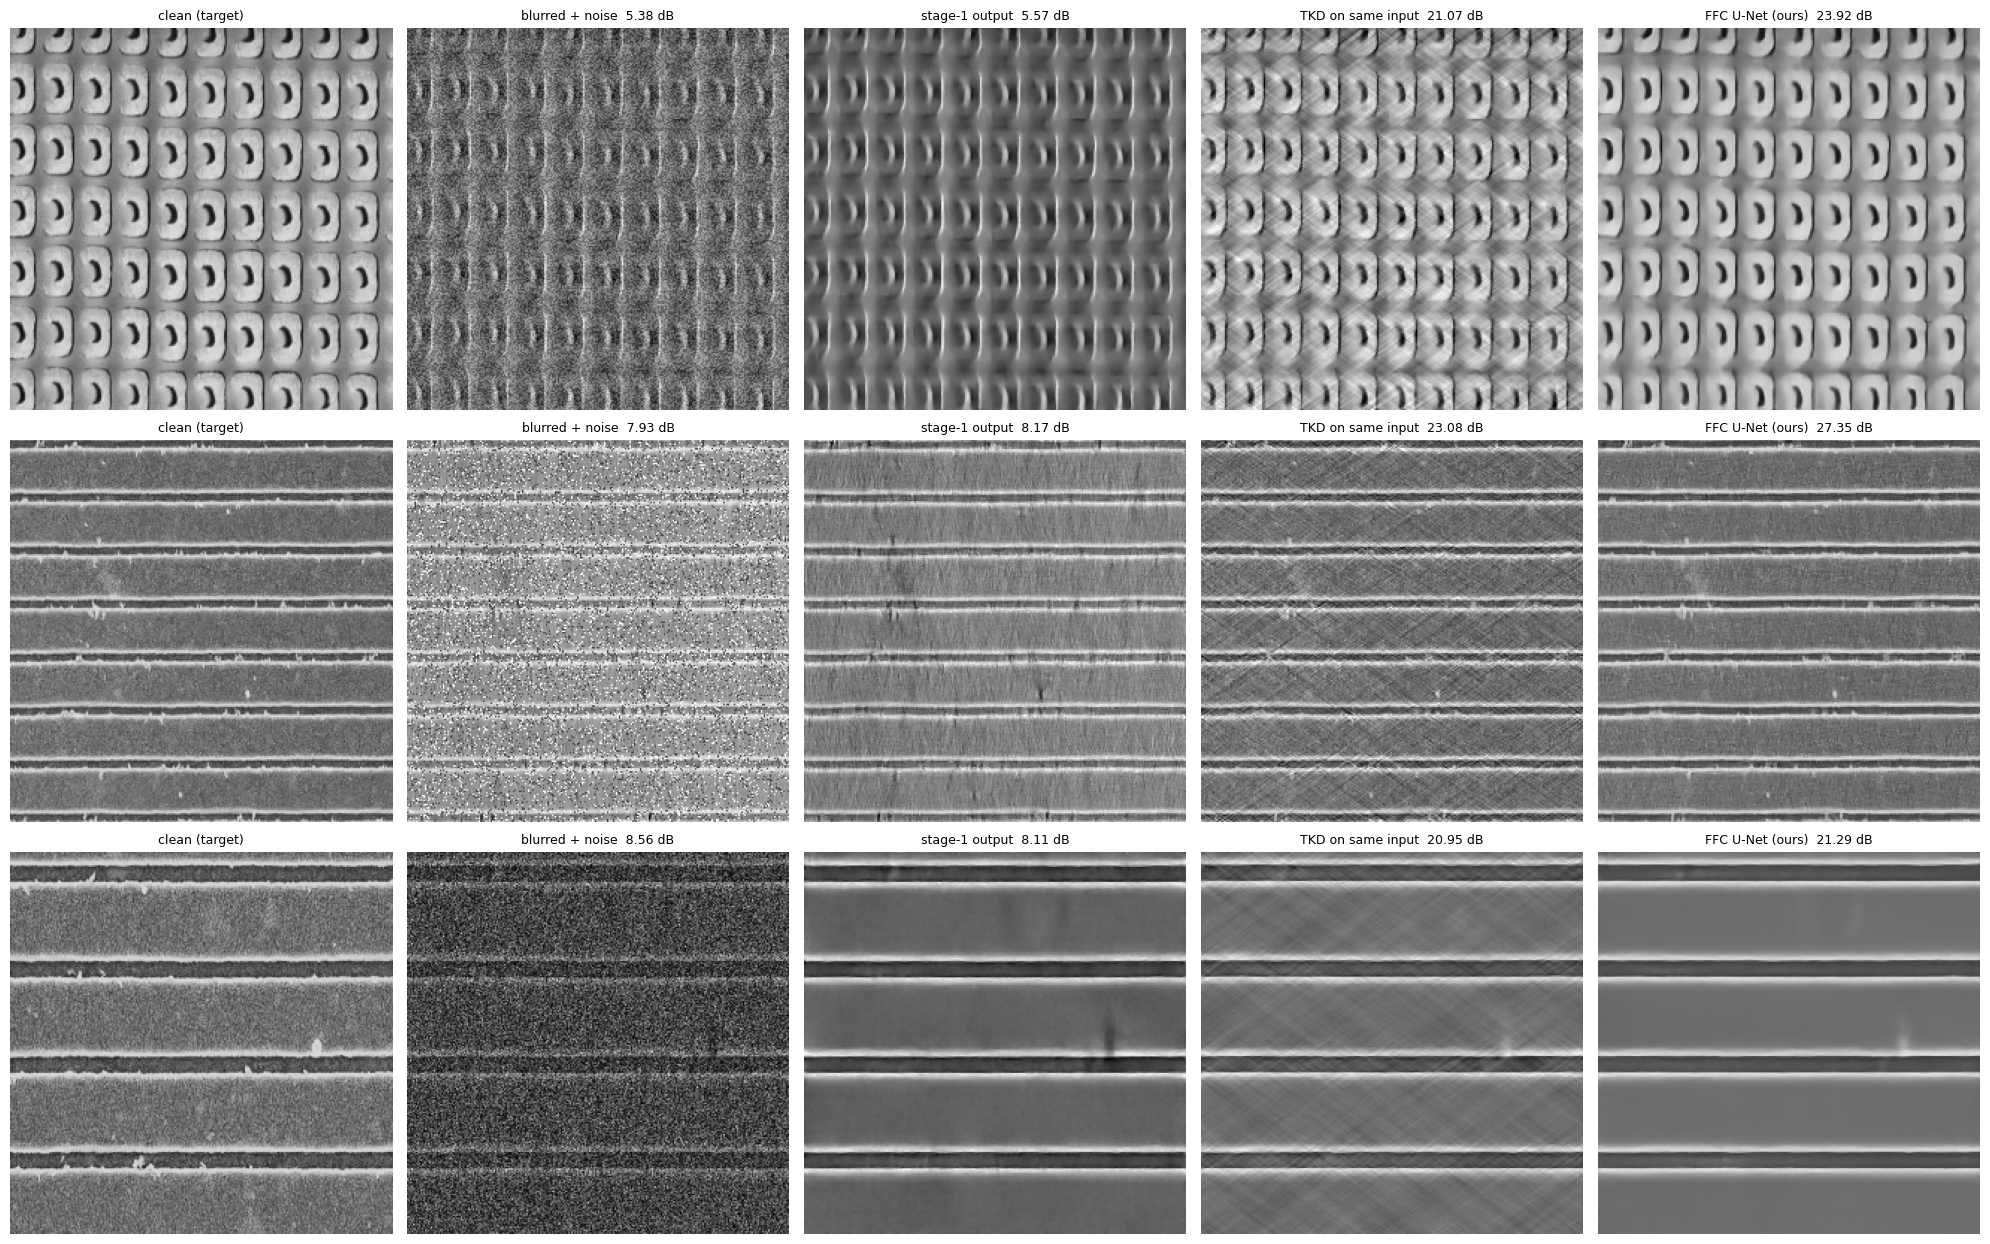

In [ ]:
import matplotlib.pyplot as plt

label, raw, blurred, _, names = next(iter(test_loader))
label = label.to(device); raw = raw.to(device); blurred = blurred.to(device)
with torch.no_grad():
    x = to_stage2_input(raw)
    pred = net(x).float()
outs = [("clean (target)", label), ("blurred + noise", raw),
        ("stage-1 output", x), ("TKD on same input", tkd_inverse(x, kern)),
        ("FFC U-Net (ours)", pred)]

n = min(3, label.shape[0])
fig, axes = plt.subplots(n, len(outs), figsize=(4.0 * len(outs), 4.2 * n))
axes = np.asarray(axes).reshape(n, len(outs))
for r in range(n):
    ref = label[r:r+1]
    vmax = float(np.percentile(label[r, 0].cpu().numpy(), 98) * 1.2)
    for c, (title, img) in enumerate(outs):
        lo, hi = (0, vmax) if c in (0, 3, 4) else (None, None)
        axes[r, c].imshow(img[r, 0].cpu().numpy(), cmap="gray", vmin=lo, vmax=hi)
        t = title if c == 0 else f"{title}  {calculate_psnr(img[r:r+1], ref).item():.2f} dB"
        axes[r, c].set_title(t, fontsize=9); axes[r, c].axis("off")
fig.tight_layout()
fig.savefig(RUN_DIR / "ffc_grid.png", dpi=140, bbox_inches="tight")
plt.show()

In [ ]:
# ═══ 무학습 부스터 1/3: 후보 정의 + val 탐색 ═══════════════════════════════
# 학습 없이 점수를 올리는 후보들을 val 100장에서 겨룬다.
#  - 뒤집기 앙상블: 다이폴(B0=(0,1))과 정확히 교환 가능한 4개 변환의 평균
#    (좌우/상하/180도. 90도 회전은 교환 불가라 쓰면 안 된다 — 수치로 검증함)
#  - hard 일관성: |D|>t 인 주파수는 순방향 모델의 정확한 역산값으로 교체
#  - soft 일관성: 주파수별로 D^2/(D^2+K) 만큼 측정을 믿는 연속 혼합.
#    위너를 '그대로' 쓰는 게 아니라 신경망 출력과 섞는 multi-K 계열 (조교 용인)
assert STAGE1_MODE == "frozen", "부스터는 frozen 파이프라인 전용"
_best = torch.load(LOCAL_BEST if LOCAL_BEST.exists() else CKPT_BEST,
                   map_location=device, weights_only=False)
net.load_state_dict(_best["model_state_dict"]); net.eval(); stage1.eval()
print(f"best checkpoint: epoch {_best['epoch'] + 1}, val PSNR {_best['best_psnr']:.3f}")

Dk = KERNELS_GPU[VAL_ORIENTATION]
FLIPS = [lambda z: z,
         lambda z: torch.flip(z, dims=[-1]),
         lambda z: torch.flip(z, dims=[-2]),
         lambda z: torch.flip(z, dims=[-1, -2])]


@torch.no_grad()
def run_pipeline(raw, ens):
    """손상 입력 -> (2단계 출력 y, 1단계 출력 b). ens=True 면 뒤집기 4개 평균."""
    ys, bs = [], []
    for f in (FLIPS if ens else FLIPS[:1]):
        r = f(raw)
        if amp_dtype is not None:
            with torch.autocast("cuda", dtype=amp_dtype):
                b = stage1(r).float()
                y = net(b).float()
        else:
            b = stage1(r); y = net(b)
        ys.append(f(y)); bs.append(f(b))          # 뒤집기는 자기 자신이 역변환
    return torch.stack(ys).mean(0), torch.stack(bs).mean(0)


def hard_dc(y, b, t):
    P = torch.fft.fftn(y, dim=(-2, -1)); B = torch.fft.fftn(b, dim=(-2, -1))
    m = Dk.abs() > t
    P = torch.where(m, B / torch.where(m, Dk, torch.ones_like(Dk)), P)
    return torch.fft.ifftn(P, dim=(-2, -1)).real


def soft_dc(y, b, K):
    P = torch.fft.fftn(y, dim=(-2, -1)); B = torch.fft.fftn(b, dim=(-2, -1))
    a = Dk**2 / (Dk**2 + K)
    P = (Dk * B) / (Dk**2 + K) + (1 - a) * P      # a*(B/D) 를 나눗셈 폭발 없이
    return torch.fft.ifftn(P, dim=(-2, -1)).real


CAND = {"그대로": lambda y, b: y}
for _t in (0.05, 0.1, 0.15, 0.2, 0.3):
    CAND[f"hard t={_t:g}"] = (lambda tt: lambda y, b: hard_dc(y, b, tt))(_t)
for _K in (1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2):
    CAND[f"soft K={_K:g}"] = (lambda KK: lambda y, b: soft_dc(y, b, KK))(_K)

BOOST = {}
for _ens in (False, True):
    _acc = {nm: [] for nm in CAND}
    for label, raw, _, _, _ in tqdm(val_loader, desc=f"val 앙상블={_ens}", leave=False):
        label, raw = label.to(device), raw.to(device)
        y, b = run_pipeline(raw, _ens)
        for nm, fn in CAND.items():
            _acc[nm].append(calculate_psnr(fn(y, b), label).flatten())
    for nm in CAND:
        BOOST[(_ens, nm)] = torch.cat(_acc[nm]).mean().item()

_base = BOOST[(False, "그대로")]
print(f"\n{'앙상블':>6} {'후보':>14} {'val PSNR':>10}")
for (e, nm), p in sorted(BOOST.items(), key=lambda kv: -kv[1]):
    print(f"{('4배' if e else '없음'):>6} {nm:>14} {p:>10.3f}   ({p - _base:+.3f})")

In [ ]:
# ═══ 무학습 부스터 2/3: multi-K 융합 ═══════════════════════════════════════
# [신경망 출력, 위너형 역산 K1/K2/K3] 네 장을 val 에서 닫힌형 최소제곱으로 푼
# 가중치 4개로 섞는다. 학습이 아니라 캘리브레이션이다 (몇 초).
BEST_ENS = max(BOOST, key=BOOST.get)[0]
CANDS_K = [3e-4, 3e-3, 3e-2]                     # 약/중/강 정규화 — 대역을 나눠 맡는다


def wiener_k(b, K):
    B = torch.fft.fftn(b, dim=(-2, -1))
    return torch.fft.ifftn(Dk * B / (Dk**2 + K), dim=(-2, -1)).real


_n = 1 + len(CANDS_K)
_G = torch.zeros(_n, _n, dtype=torch.float64, device=device)
_v = torch.zeros(_n, dtype=torch.float64, device=device)
with torch.no_grad():
    for label, raw, _, _, _ in tqdm(val_loader, desc="융합 가중치 적합", leave=False):
        label, raw = label.to(device), raw.to(device)
        y, b = run_pipeline(raw, BEST_ENS)
        A = torch.stack([y] + [wiener_k(b, K) for K in CANDS_K], -1).reshape(-1, _n).double()
        _G += A.T @ A
        _v += A.T @ label.reshape(-1).double()
W_FUSION = torch.linalg.solve(_G, _v)
print("융합 가중치 (신경망, K1, K2, K3):", [f"{x:+.3f}" for x in W_FUSION.tolist()])


def fusion(y, b):
    A = torch.stack([y] + [wiener_k(b, K) for K in CANDS_K], -1)
    return (A.double() @ W_FUSION).float()


CAND["multi-K 융합"] = fusion
_acc = []
with torch.no_grad():
    for label, raw, _, _, _ in val_loader:
        label, raw = label.to(device), raw.to(device)
        y, b = run_pipeline(raw, BEST_ENS)
        _acc.append(calculate_psnr(fusion(y, b), label).flatten())
BOOST[(BEST_ENS, "multi-K 융합")] = torch.cat(_acc).mean().item()
print(f"multi-K 융합  val PSNR {BOOST[(BEST_ENS, 'multi-K 융합')]:.3f}"
      f"   (기본 {_base:.3f} 대비 {BOOST[(BEST_ENS, 'multi-K 융합')] - _base:+.3f})")

In [ ]:
# ═══ 무학습 부스터 3/3: val 1등 조합으로 주최측 쌍 최종 평가 ═══════════════
# test 는 점수 확인 용도로만 — 여기 한 번이다. 발표에 쓸 공식 숫자.
import zipfile

if not any((LOCAL_ROOT / "test_deconv_noise").glob("**/*.npy")):
    _z = DRIVE_ROOT / "dataset_deconv.zip"
    assert _z.exists(), "Drive 의 project5 에 dataset_deconv.zip 을 올릴 것"
    with zipfile.ZipFile(_z) as f:
        f.extractall(LOCAL_ROOT)


def _npy_dir(base):
    return base if any(base.glob("*.npy")) else next(
        d for d in sorted(base.iterdir()) if any(d.glob("*.npy")))


NOISE_DIR = _npy_dir(LOCAL_ROOT / "test_deconv_noise")
LABEL_DIR = _npy_dir(LOCAL_ROOT / "test_label")

ENS_PICK, NAME_PICK = max(BOOST, key=BOOST.get)
FN_PICK = CAND[NAME_PICK]
print(f"val 1등 조합: 앙상블={'4배' if ENS_PICK else '없음'}, {NAME_PICK}"
      f"  (val {BOOST[(ENS_PICK, NAME_PICK)]:.3f} dB)")

names = sorted(p.name for p in LABEL_DIR.glob("*.npy"))
_missing = [n for n in names if not (NOISE_DIR / n).exists()]
assert not _missing, f"이름이 안 맞는 파일: {_missing[:3]}"

res = {"기본 (부스터 없음)": [[], []], "선택 조합": [[], []]}
with torch.no_grad():
    for i in range(0, len(names), 8):
        bat = names[i:i + 8]
        noisy = torch.stack([load_npy(NOISE_DIR / n) for n in bat]).to(device)
        label = torch.stack([load_npy(LABEL_DIR / n) for n in bat]).to(device)
        y0, b0 = run_pipeline(noisy, False)
        res["기본 (부스터 없음)"][0].append(calculate_psnr(y0, label).flatten())
        res["기본 (부스터 없음)"][1].append(calculate_ssim(y0, label).flatten())
        y, b = (y0, b0) if not ENS_PICK else run_pipeline(noisy, True)
        out = FN_PICK(y, b)
        res["선택 조합"][0].append(calculate_psnr(out, label).flatten())
        res["선택 조합"][1].append(calculate_ssim(out, label).flatten())

print(f"\n주최측 쌍 {len(names)}장 — 공식 조건")
for nm, (p, s) in res.items():
    print(f"  {nm:<16} PSNR {torch.cat(p).mean().item():7.3f}   SSIM {torch.cat(s).mean().item():.4f}")
print("  (조교 end-to-end U-Net 25.02 와 같은 기준)")

In [ ]:
# ═══ 발표용 추론 그림: 잡음 종류별 행 × (원본/번짐+잡음/복원/오차 지도/확대) ═══
# 정성 관찰은 규칙에 따라 val 영상으로 한다. 행마다 서로 다른 영상을 써서 다양한
# 사례를 보인다. 부스터 셀 1/3 이 먼저 실행돼 있어야 한다 (run_pipeline 필요).
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches

if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
    !apt-get -qq install -y fonts-nanum > /dev/null 2>&1
    fm._load_fontmanager(try_read_cache=False)
KO = next((c for c in ("NanumGothic", "Malgun Gothic") if any(f.name == c for f in fm.fontManager.ttflist)), "")
if KO:
    plt.rcParams["font.family"] = KO
plt.rcParams["axes.unicode_minus"] = False
L = lambda ko, en: ko if KO else en

USE_ENS = True                    # 최종 방법 = 뒤집기 4배 앙상블
CS = 64                           # 확대 영역의 한 변 (픽셀)
PICK_IDX = [0, 1, 2, 3]           # 행마다 쓸 val 영상 번호 — 사례를 바꾸려면 여기만 수정
KERNEL_GPU = KERNELS[VAL_ORIENTATION].to(device)

val_files = sorted(VAL_DIR.glob("*.npy"))
assert max(PICK_IDX) < len(val_files), f"val 영상은 {len(val_files)}장뿐이다"

rows_fig = []
for k, (nz, idx) in enumerate(zip(NOISE_NAMES, PICK_IDX)):
    label = load_npy(val_files[idx]).unsqueeze(0).to(device)      # 행마다 다른 영상
    blurred = apply_dipole(label, KERNEL_GPU)
    lo, hi = NOISE_RANGES[nz]
    st = torch.random.get_rng_state(); torch.manual_seed(k + 1)   # 재현 가능하게
    try:
        noisy = NOISE_FUNCS[nz](blurred, (lo + hi) / 2)           # 세기 = 범위의 중간
    finally:
        torch.random.set_rng_state(st)
    y, _ = run_pipeline(noisy, USE_ENS)
    rows_fig.append((nz, val_files[idx].stem, label, noisy, y))

fig, axes = plt.subplots(4, 5, figsize=(3.3 * 5, 3.6 * 4))

for r, (nz, stem, label, noisy, y) in enumerate(rows_fig):
    c_np = label[0, 0].cpu().numpy()
    vmin = float(np.percentile(c_np, 1)); vmax = float(np.percentile(c_np, 99))
    y_np = y[0, 0].float().cpu().numpy()
    n_np = noisy[0, 0].float().cpu().numpy()
    err = np.abs(y_np - c_np)
    # 오차가 가장 큰 곳을 확대한다 (영상마다 볼 자리가 다르므로 자동으로 고른다)
    sm = F.avg_pool2d(torch.from_numpy(err)[None, None], CS, stride=CS // 2)[0, 0]
    fy, fx = np.unravel_index(int(sm.argmax()), sm.shape)
    CY, CX = int(fy * CS // 2), int(fx * CS // 2)
    p_in = calculate_psnr(noisy.float(), label).item()
    p_out = calculate_psnr(y.float(), label).item()
    panels = [
        (c_np, L("원본", "clean"), "gray", (vmin, vmax)),
        (n_np, f'{L("번짐+잡음", "input")}  {p_in:.1f} dB', "gray", (None, None)),
        (y_np, f'{L("복원", "restored")}  {p_out:.1f} dB', "gray", (vmin, vmax)),
        (err, f'{L("오차 지도", "|error|")}  max {err.max():.2f}', "magma",
         (0.0, float(np.percentile(err, 99.5)))),
        (y_np[CY:CY + CS, CX:CX + CS], L("복원 확대", "zoom"), "gray", (vmin, vmax)),
    ]
    for c, (im, ttl, cmap, (v0, v1)) in enumerate(panels):
        ax = axes[r, c]
        ax.imshow(im, cmap=cmap, vmin=v0, vmax=v1)
        ax.set_title(ttl, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
        if c == 0:
            ax.set_ylabel(nz + "\n(" + stem + ")", fontsize=11, fontweight="bold")
    # 확대한 자리를 복원 패널에 빨간 상자로 표시
    axes[r, 2].add_patch(mpatches.Rectangle((CX, CY), CS, CS, fill=False,
                                            edgecolor="red", lw=1.3))

fig.suptitle(L("두 단계 FFC 파이프라인 복원 결과 — 서로 다른 영상 4장, 잡음 4종 (val)",
               "Two-stage FFC results: four different images, four noise types (val)"), fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(RUN_DIR / "inference_grid.png", dpi=140, bbox_inches="tight")
plt.show()
print("저장:", RUN_DIR / "inference_grid.png")